In [2]:
import os
import glob
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dask.array as da

In [2]:
pip install xarray dask netCDF4 h5netcdf matplotlib


Note: you may need to restart the kernel to use updated packages.


In [3]:
SST=xr.open_dataset(r"C:\Users\paola\Tesis\01_Data\SST\sst.day.mean.1988.nc")

In [4]:
SST

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 366, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1988-01-01 1988-01-02 ... 1988-12-31
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, lat, lon) float32 2GB ...
Attributes:
    Conventions:    CF-1.5
    title:          NOAA High-resolution Blended Analysis: Daily Values using...
    institution:    NOAA/NCDC
    source:         NOAA/NCDC  ftp://eclipse.ncdc.noaa.gov/pub/OI-daily-v2/
    history:        Thu Aug 24 13:38:49 2017: ncatted -O -a References,global...
    dataset_title:  NOAA Daily Optimum Interpolation Sea Surface Temperature
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    comment:        Reynolds, et al.(2007) Daily High-Resolution-Blended Anal...

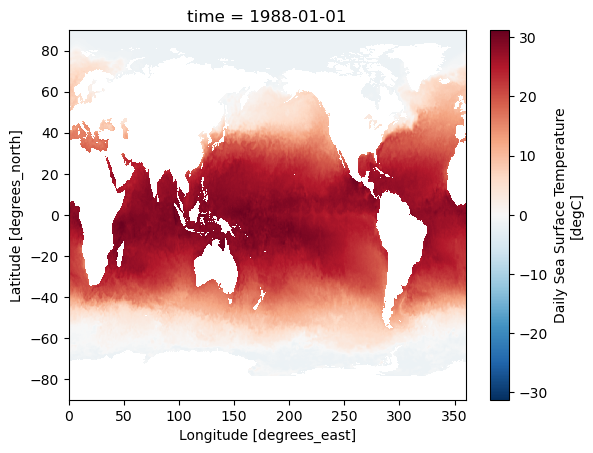

In [5]:
#SST.sst.mean(dim="time").plot()
SST.sst[0,:,:].plot()


In [5]:
import xarray as xr
import numpy as np

# === 1. Cargar datos diarios ===
ruta = r"C:\Users\paola\Tesis\01_Data\SST\sst.day.mean.*.nc"

SST = xr.open_mfdataset(
    ruta,
    combine='by_coords',
    parallel=True,
    chunks={'time': 366}
)

print("Dataset cargado correctamente.")

# === 2. Selección exacta del periodo ===
SST = SST.sel(time=slice("1981-01-01", "2025-12-31"))

# === 3. Promediar a mensual ===
SST_monthly = SST.resample(time='MS').mean()

# === 4. Seleccionar variable ===
sst = SST_monthly['sst']

# === 5. Rechunk para evitar error de dask ===
sst = sst.chunk({'time': -1})   # un solo chunk temporal

# === 6. Funcción de detrend pixel-wise ===
def detrend_pixel(x):
    mask = np.isfinite(x)
    if mask.sum() < 2:
        return np.full_like(x, np.nan)

    y = x[mask]
    t = np.arange(len(y))

    coef = np.polyfit(t, y, 1)
    trend = coef[0] * t + coef[1]

    out = np.full_like(x, np.nan)
    out[mask] = y - trend
    return out

# === 7. Aplicar detrend por pixel ===
sst_detrended = xr.apply_ufunc(
    detrend_pixel,
    sst,
    input_core_dims=[["time"]],
    output_core_dims=[["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
)

print("Detrend aplicado correctamente.")

# === 8. REMUESTREAR A 0.5° × 0.5° ===
# La SST está en 0.25°, así que coarsen(lat=2, lon=2) → 0.5°
print("Remuestreando SST a resolución 0.5° (coarsen)...")
sst_detrended_05 = sst_detrended.coarsen(lat=2, lon=2, boundary="trim").mean()

# Renombrar variable
sst_detrended_05 = sst_detrended_05.rename("sst_detrended")

# === 9. Guardar dataset final ===
output = r"C:\Users\paola\Tesis\02_Procesados\SST_monthly_detrended_1981_2025_0p5deg.nc"

sst_detrended_05.to_netcdf(output, format='NETCDF4', mode='w', compute=True)

print("====================================================")
print(f"✅ Archivo mensual detrendido + remuestreado guardado:")
print(output)
print("Resolución final:", float(sst_detrended_05.lat[1] - sst_detrended_05.lat[0]), "°")
print("====================================================")


Dataset cargado correctamente.
Detrend aplicado correctamente.
Remuestreando SST a resolución 0.5° (coarsen)...
✅ Archivo mensual detrendido + remuestreado guardado:
C:\Users\paola\Tesis\02_Procesados\SST_monthly_detrended_1981_2025_0p5deg.nc
Resolución final: 0.5 °
